In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
import sys
from packaging import version
import sklearn

if sys.version_info < (3, 7):
        raise ValueError(f"Python version must be 3.7 or higher. Found: {sys.version_info.major}.{sys.version_info.minor}")

if version.parse(sklearn.__version__) < version.parse("1.0.1"):
        raise ValueError(f"Scikit-learn version must be 1.0.1 or higher. Found: {sklearn.__version__}")

print("Environment checks passed: Python and Scikit-learn versions meet requirements.")

Environment checks passed: Python and Scikit-learn versions meet requirements.


In [3]:
#Task 1
from pathlib import Path
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter='data')
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
print("Housing data loaded successfully.")

Housing data loaded successfully.


In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

if not isinstance(housing.index, pd.RangeIndex):
    housing.reset_index(drop=True, inplace=True)

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numeric and categorical columns based on `strat_train_set`.
# `num_attribs` should contain all numerical features, excluding the target (`median_house_value`)
# and the categorical feature (`ocean_proximity`). `income_cat` has already been dropped from `strat_train_set`.
numerical_features = strat_train_set.select_dtypes(include=np.number).columns.tolist()
if "median_house_value" in numerical_features:
    numerical_features.remove("median_house_value")
num_attribs = numerical_features

cat_attribs = ["ocean_proximity"]

# Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])

# Full Column Transformer (Note: This `full_pipeline` and `housing_prepared` are not used for model training later on in the notebook.)
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# The original line `housing_prepared = full_pipeline.fit_transform(housing)` used the global `housing` DataFrame.
# As `housing_prepared` is not used subsequently and the `num_attribs` are now derived from `strat_train_set`,
# this line is removed to avoid potential inconsistencies and for clarity.
# If `housing_prepared` were needed, the `housing` DataFrame would also need appropriate preprocessing for its columns.

In [7]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# Define strat_housing_num from strat_train_set using the previously defined num_attribs
strat_housing_num = strat_train_set[num_attribs]

strat_housing_num_std_scaled = std_scaler.fit_transform(strat_housing_num)

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

def default_num_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
], remainder=default_num_pipeline())

In [9]:
strat_housing_prepared = preprocessing.fit_transform(strat_train_set)
strat_housing_prepared.shape

(16512, 25)

In [10]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__median_house_value'],
      dtype=object)

In [11]:
#Lab 3
#Task 4
#Task 4:1 - Modelpipeline

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

strat_housing = strat_train_set.drop("median_house_value", axis=1)
strat_housing_labels = strat_train_set["median_house_value"].copy()

lin_reg = make_pipeline(preprocessing, LinearRegression())

#Task 4:2 - Training
lin_reg.fit(strat_housing, strat_housing_labels)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
#Task 4:3 - Initial prediction
strat_housing_predictions = lin_reg.predict(strat_housing)

strat_housing_predictions[:5].round(-2)

array([242800., 375900., 127500.,  99400., 324600.])

In [13]:
#Compare against actual values
strat_housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [14]:
error_ratios = strat_housing_predictions[:5].round(-2) / strat_housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-47.0%, -22.3%, 25.4%, 3.4%, -10.3%


In [15]:
#Task 4:4 - Error metric
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate the Root Mean Squared Error (RMSE) of the predictions made by the linear regression model
lin_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

In [16]:
print("Linear Regression RMSE:", lin_rmse)

Linear Regression RMSE: 68647.95686706711


In [17]:
#Task 4:5
#The model is off by about $68k, which is a big error. 
#It’s too simple to catch all the patterns.

In [18]:
#Task 5
#Task 5:1 - Algorithm swap

from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))

tree_reg.fit(strat_housing, strat_housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
#Task 5:2 - Comparision
strat_housing_predictions = tree_reg.predict(strat_housing)
tree_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

In [20]:
print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 0.0


In [21]:
#Task 5:3 - Overfitting mystery

#The tree can get very complex and memorize all the training data. 
#That’s called overfitting, and it means it won’t work well on new data.

In [22]:
#Task 6
#Task 6:1 - K-fold CV

from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation using randomly splitted training set on the Decision Tree Regressor
# The negative sign is because cross_val_score returns negative values for metrics where lower is better
tree_rmses = -cross_val_score(tree_reg, strat_housing, strat_housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [23]:
#Task 6:2 - Utility function
pd.Series(tree_rmses).describe()

count       10.000000
mean     66366.983603
std       1976.844743
min      63557.655007
25%      65004.623899
50%      65886.897085
75%      68129.026040
max      69530.301101
dtype: float64

In [24]:
#Task 6:1 & 6:2

#computes the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, strat_housing, strat_housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     69847.923224
std       4078.407329
min      65659.761079
25%      68088.799156
50%      68697.591463
75%      69800.966364
max      80685.254832
dtype: float64

In [25]:
#Task 6:3 - Comparision

#Because the tree overfits, it learns random noise and details that don’t apply to new data. 
#Cross-validation tests it on new data and shows it actually performs poorly.

In [26]:
#Task 7
#Task 7:1 - Ensemble learning

from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))

forest_rmses = -cross_val_score(forest_reg, strat_housing, strat_housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [27]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     46938.209246
std       1018.397196
min      45522.649195
25%      46291.334639
50%      47021.703303
75%      47321.521991
max      49140.832210
dtype: float64

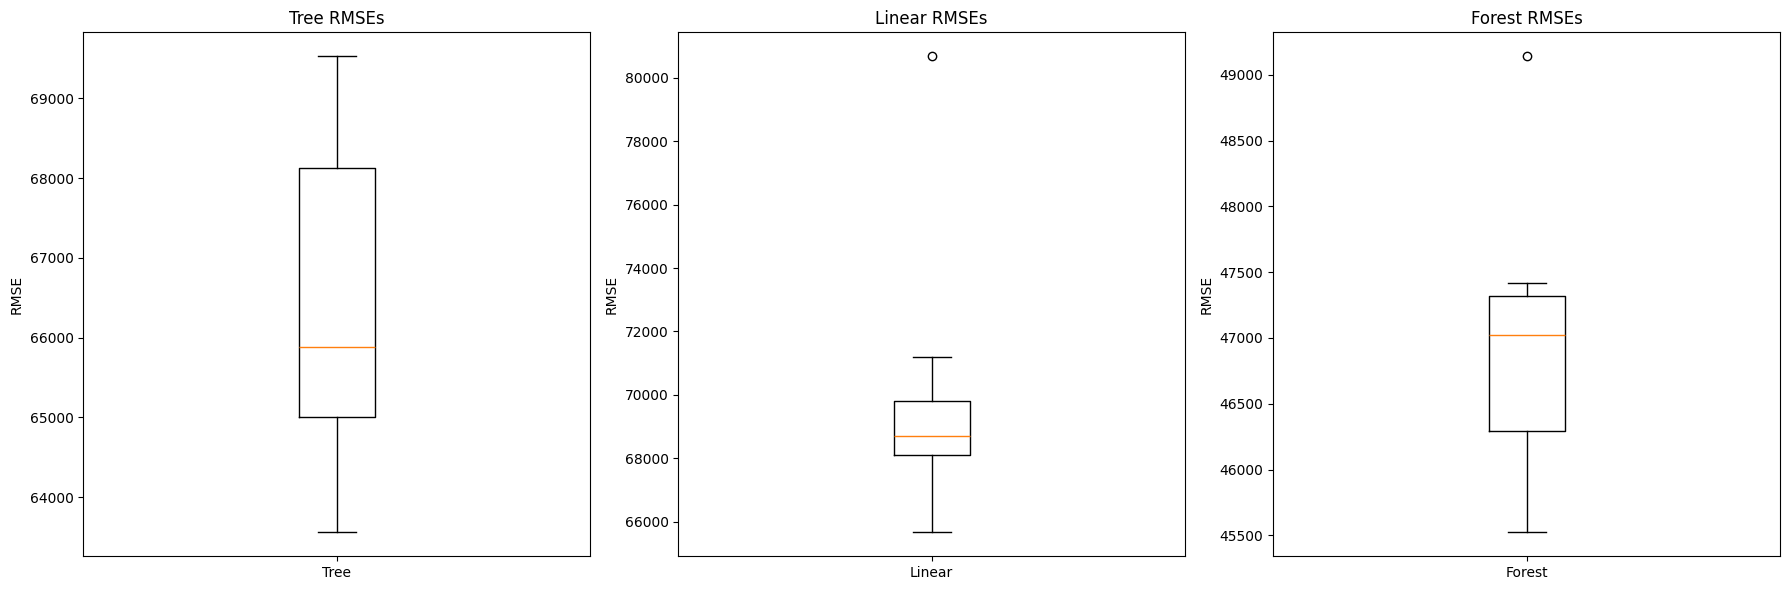

In [28]:
#Task 7:2 - Visualization 
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Tree RMSEs': tree_rmses,
    'Linear RMSEs': lin_rmses,
    'Forest RMSEs': forest_rmses
})

# Plotting
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Boxplot for Tree RMSEs
axes[0].boxplot(data['Tree RMSEs'])
axes[0].set_title('Tree RMSEs')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Tree'])

# Boxplot for Linear RMSEs
axes[1].boxplot(data['Linear RMSEs'])
axes[1].set_title('Linear RMSEs')
axes[1].set_ylabel('RMSE')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Linear'])

# Boxplot for Forest RMSEs
axes[2].boxplot(data['Forest RMSEs'])
axes[2].set_title('Forest RMSEs')
axes[2].set_ylabel('RMSE')
axes[2].set_xticks([1])
axes[2].set_xticklabels(['Forest'])

# Show the plot
plt.tight_layout()
plt.show()

In [29]:
forest_reg.fit(strat_housing, strat_housing_labels)

strat_housing_predictions = forest_reg.predict(strat_housing)

forest_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

In [30]:
print("Random Forest RMSE on training data:", forest_rmse)

Random Forest RMSE on training data: 17521.565358779884


In [31]:
#Task 7:3 - Analysis
#Random Forest is most stable (lowest variance) and most accurate (lowest mean RMSE). 
#Ensemble averaging reduces overfitting.

In [32]:
#Task 8
#Task 8:1 - Grid Search

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

# Define the grid of hyperparameters to search
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10], # Number of clusters for geographical similarity
     'random_forest__max_features': [4, 6, 8]},  # Number of features to consider at each split
    {'preprocessing__geo__n_clusters': [10, 15],  # Additional values for number of clusters
     'random_forest__max_features': [6, 8, 10]},  # Additional values for number of features
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')

grid_search.fit(strat_housing, strat_housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"


In [33]:
#Shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

In [34]:
#Task 8:2 - Results inspection
print("Best parameters:", grid_search.best_params_)
print("Best RMSE score:", -grid_search.best_score_)

Best parameters: {'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}
Best RMSE score: 43616.07551705611


In [35]:
#displays overall pipeline
grid_search.best_estimator_

,steps,"[('preprocessing', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43007,43683,44158,43616
13,15,8,43697,44011,44819,44176
7,10,6,43710,44133,45227,44356
9,10,6,43710,44133,45227,44356
6,10,4,43798,44233,45100,44377


In [37]:
#Task 8:3 - Randomized search

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the distribution of hyperparameters to sample from
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50), #samples integer values between 3 and 49 for the number of clusters
                  'random_forest__max_features': randint(low=2, high=20)} #samples integer values between 2 and 19 for the number of features

# Create a RandomizedSearchCV object
# 'full_pipeline' is the pipeline that includes preprocessing and the model
# 'param_distributions' specifies the distributions to sample hyperparameters from
# 'n_iter=10' specifies the number of parameter settings that are sampled
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="neg_root_mean_squared_error"' specifies that we want to minimize the RMSE
# 'random_state=42' ensures reproducibility of the random sampling
rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

# Perform the randomized search on the training data
rnd_search.fit(strat_housing, strat_housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'preprocessing__geo__n_clusters': <scipy.stats....0019A24DD8190>, 'random_forest__max_features': <scipy.stats....0019A24E199D0>}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
#  displays the random search results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41226,42385,42712,42108
8,32,7,41374,42579,43230,42394
0,41,16,42397,42640,43175,42738
5,42,4,41761,43348,43690,42933
2,23,8,42421,43138,43585,43048


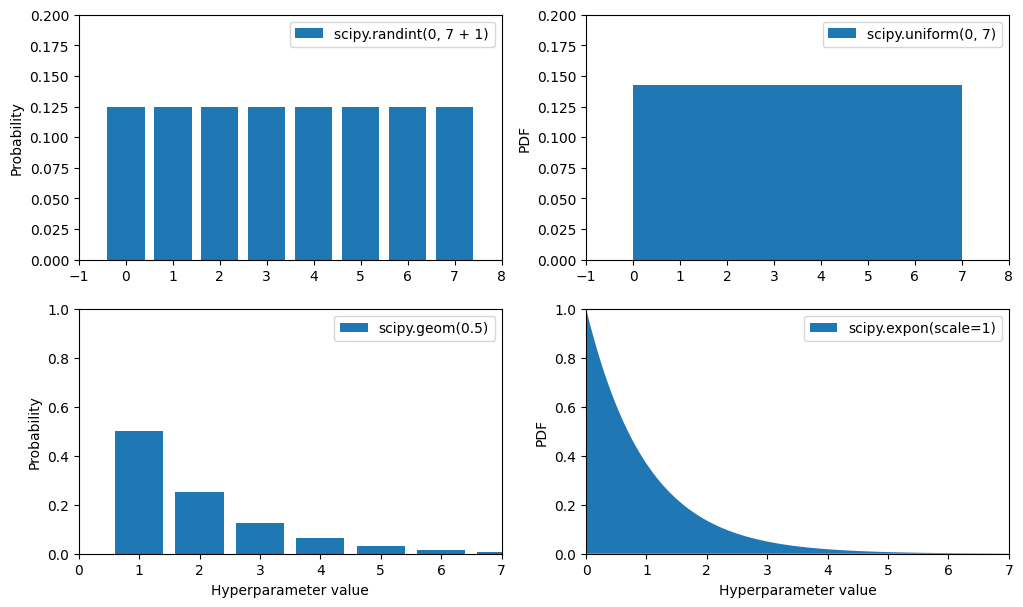

In [39]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

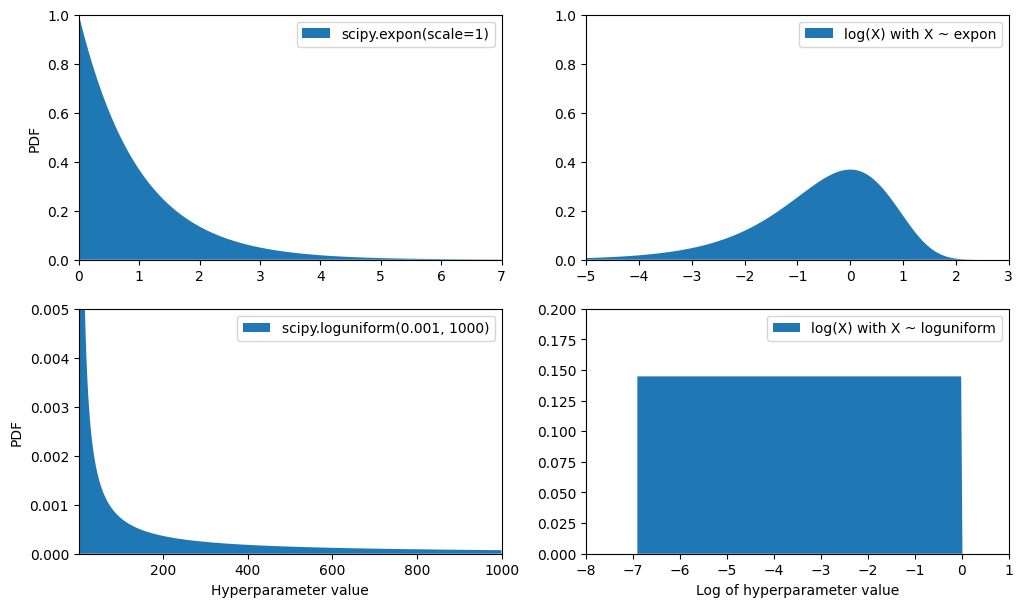

In [42]:
#Shows the difference between expon and loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

In [43]:
#Task 8:4 - Feature importance

final_model = rnd_search.best_estimator_  

feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.02, 0.01, 0.  , 0.01,
       0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [44]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(np.float64(0.18883049114642353), 'log__median_income'),
 (np.float64(0.07550690165952419), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06427087748676082), 'bedrooms__ratio'),
 (np.float64(0.0521695509969851), 'rooms_per_house__ratio'),
 (np.float64(0.04664258696240615), 'people_per_house__ratio'),
 (np.float64(0.04244311259449021), 'geo__Cluster 3 similarity'),
 (np.float64(0.02329106317954673), 'geo__Cluster 17 similarity'),
 (np.float64(0.022649484211911694), 'geo__Cluster 18 similarity'),
 (np.float64(0.02197243576680579), 'geo__Cluster 22 similarity'),
 (np.float64(0.01881537204558837), 'geo__Cluster 40 similarity'),
 (np.float64(0.017669986767360032), 'geo__Cluster 10 similarity'),
 (np.float64(0.01754694953848625), 'geo__Cluster 35 similarity'),
 (np.float64(0.017274903717750808), 'geo__Cluster 41 similarity'),
 (np.float64(0.0160556631074201), 'geo__Cluster 6 similarity'),
 (np.float64(0.015811758952117744), 'geo__Cluster 2 similarity'),
 (np.float64(0.01477755940463033), '

In [45]:
#Task 9
#Task 9:1 - The Final Test

X_test = strat_test_set.drop("median_house_value", axis=1)

y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

In [46]:
print("Predicted values:", final_predictions[:5])

print("Actual values:", y_test[:5].values)

Predicted values: [415116.29 214128.   353359.2  331427.   270297.02]
Actual values: [397700. 202900. 310000. 314300. 187500.]


In [47]:
#Task 9:1 still
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(final_rmse) 

41556.053474456494


In [48]:
#Task 9:2 - Confidence intervall (Calculate 95)
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([39415.11928419, 43591.96637635])

In [49]:
#Task 9:3 - Caution
#The test set should only be used once to check final performance. 
#If you keep adjusting the model based on it, you’re basically training on it, 
#which leads to overfitting and overly optimistic (but misleading) results.

In [50]:
#Task 10
#Task 10:1 - Saving

import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

In [51]:
#Task 10:2 - Loading 

import joblib

# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

# Note that you will still need your pipelines to transform your nea real world data.
def column_ratio(X):
      return X[:, [0]] / X[:, [1]]

# Load the trained model from the file
# This allows the model to be used without retraining
final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [52]:
predictions

array([434691.11, 375226.06, 381995.1 , 341939.  , 322273.  ])